##### ***HPF***

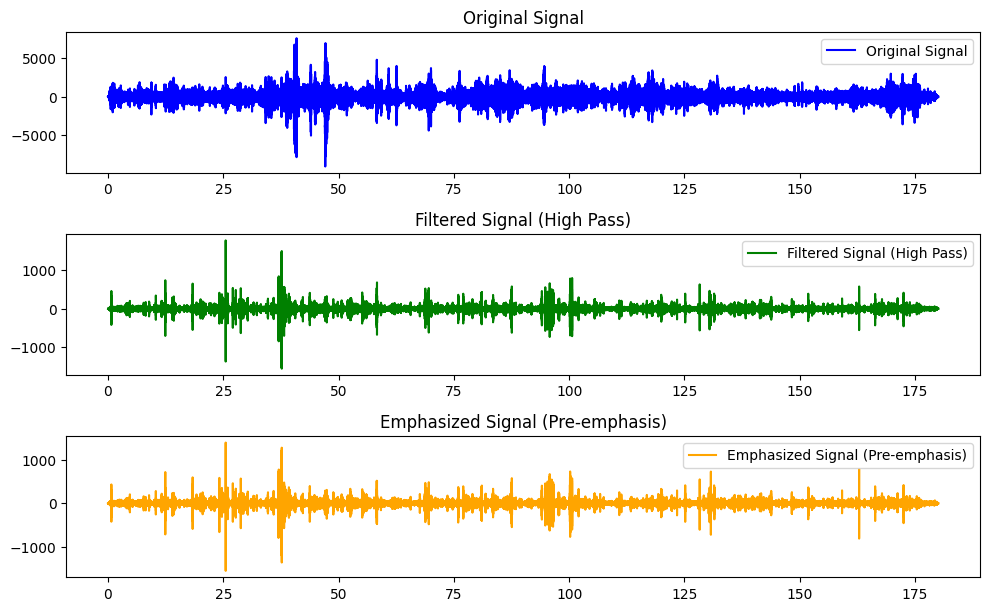

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from scipy.signal import butter, filtfilt

# Fungsi high-pass filter
def high_pass_filter(data, cutoff, fs, order=4):
    nyquist = 0.5 * fs
    normal_cutoff = cutoff / nyquist
    b, a = butter(order, normal_cutoff, btype='high', analog=False)
    filtered_signal = filtfilt(b, a, data)
    return filtered_signal

# Fungsi pre-emphasis
def pre_emphasis(signal, alpha=0.95):
    emphasized_signal = np.append(signal[0], signal[1:] - alpha * signal[:-1])
    return emphasized_signal

# Memuat file suara
fs, signal = wavfile.read('crowded.wav')  # fs = sampling rate, signal = data audio

# Jika file audio lebih dari satu saluran (stereo), kita hanya ambil saluran pertama
if len(signal.shape) > 1:
    signal = signal[:, 0]

# Menentukan frekuensi cutoff untuk high-pass filter
cutoff_freq = 5000  # Frekuensi cutoff untuk high-pass filter

# Menggunakan high-pass filter pada sinyal audio
filtered_signal = high_pass_filter(signal, cutoff_freq, fs)

# Terapkan pre-emphasis pada sinyal yang sudah difilter
alpha = 0.95
emphasized_signal = pre_emphasis(filtered_signal, alpha)

# Menyiapkan waktu untuk plotting (berdasarkan sampling rate)
t = np.arange(0, len(signal)) / fs

# Plot sinyal asli, sinyal setelah high-pass filter, dan sinyal setelah pre-emphasis
plt.figure(figsize=(10, 8))

# Plot sinyal asli
plt.subplot(4, 1, 1)
plt.plot(t, signal, label='Original Signal', color='b')
plt.legend()
plt.title('Original Signal')

# Plot sinyal setelah high-pass filter
plt.subplot(4, 1, 2)
plt.plot(t, filtered_signal, label='Filtered Signal (High Pass)', color='g')
plt.legend()
plt.title('Filtered Signal (High Pass)')

# Plot sinyal setelah pre-emphasis
plt.subplot(4, 1, 3)
plt.plot(t, emphasized_signal, label='Emphasized Signal (Pre-emphasis)', color='orange')
plt.legend()
plt.title('Emphasized Signal (Pre-emphasis)')

# Menampilkan plot
plt.tight_layout()
plt.show()


##### ***DIF***

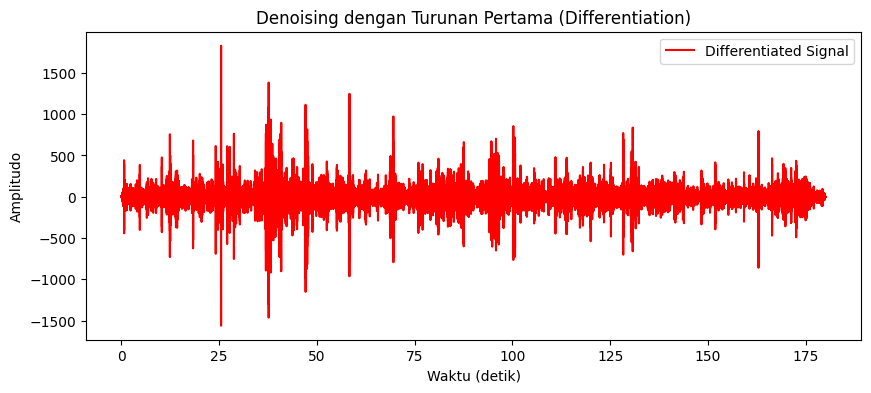

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile

# Memuat file suara
fs, signal = wavfile.read('crowded.wav')  # fs = sampling rate, signal = data audio

# Jika file audio lebih dari satu saluran (stereo), kita hanya ambil saluran pertama
if len(signal.shape) > 1:
    signal = signal[:, 0]

# Menyiapkan waktu untuk plotting (berdasarkan sampling rate)
t = np.arange(0, len(signal)) / fs

# Menghitung turunan pertama (differentiation)
diff_signal = np.diff(signal, n=1)

# Menghitung waktu untuk sinyal yang sudah dibedakan (differentiated)
diff_time = t[:-1]  # Waktu untuk sinyal yang sudah dibedakan (differentiated)

# Plot sinyal setelah differentiation (turunan pertama)
plt.figure(figsize=(10, 4))
plt.plot(diff_time, diff_signal, label='Differentiated Signal', color='r')
plt.legend()
plt.title('Denoising dengan Turunan Pertama (Differentiation)')
plt.xlabel('Waktu (detik)')
plt.ylabel('Amplitudo')
plt.show()


##### ***DWT***

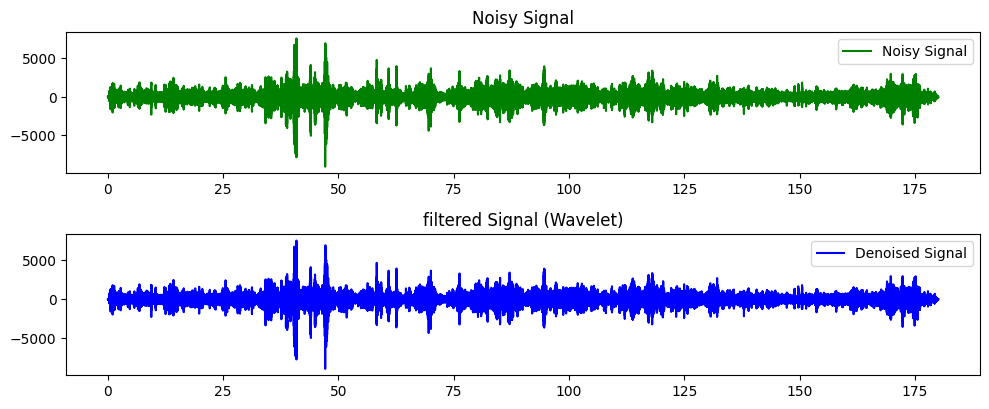

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import pywt
from scipy.io import wavfile

# Memuat file suara
fs, noisy_signal = wavfile.read('crowded.wav')  # fs = sampling rate, noisy_signal = data audio

# Jika file audio lebih dari satu saluran (stereo), kita hanya ambil saluran pertama
if len(noisy_signal.shape) > 1:
    noisy_signal = noisy_signal[:, 0]

# Menyiapkan waktu untuk plotting (berdasarkan sampling rate)
t = np.arange(0, len(noisy_signal)) / fs

# Parameter untuk wavelet
wavelet = 'db4'  # Jenis wavelet (Daubechies-4)
level = 4  # Level dekomposisi wavelet

# Dekomposisi wavelet
coeffs = pywt.wavedec(noisy_signal, wavelet, level=level)

# Menentukan threshold untuk soft thresholding
threshold = np.std(coeffs[-1]) * np.sqrt(2 * np.log(len(noisy_signal)))

# Terapkan soft thresholding pada koefisien wavelet (kecuali koefisien aproksimasi)
new_coeffs = [coeffs[0]] + [pywt.threshold(c, threshold, mode='soft') for c in coeffs[1:]]

# Rekonstruksi sinyal setelah thresholding
denoise_signal = pywt.waverec(new_coeffs, wavelet)

# Plot sinyal asli dan sinyal setelah denoising dengan wavelet
plt.figure(figsize=(10, 8))

# Plot sinyal noisy (asli)
plt.subplot(4, 1, 1)
plt.plot(t, noisy_signal, label='Noisy Signal', color='g')
plt.legend()
plt.title('Noisy Signal')

# Trim denoise_signal to match the length of t
denoise_signal = denoise_signal[:len(t)]

# Plot sinyal yang telah dide-noise dengan wavelet
plt.subplot(4, 1, 2)
plt.plot(t, denoise_signal, label='Denoised Signal', color='b')
plt.legend()
plt.title('filtered Signal (Wavelet)')

# Menampilkan plot
plt.tight_layout()
plt.show()


##### ***USM***

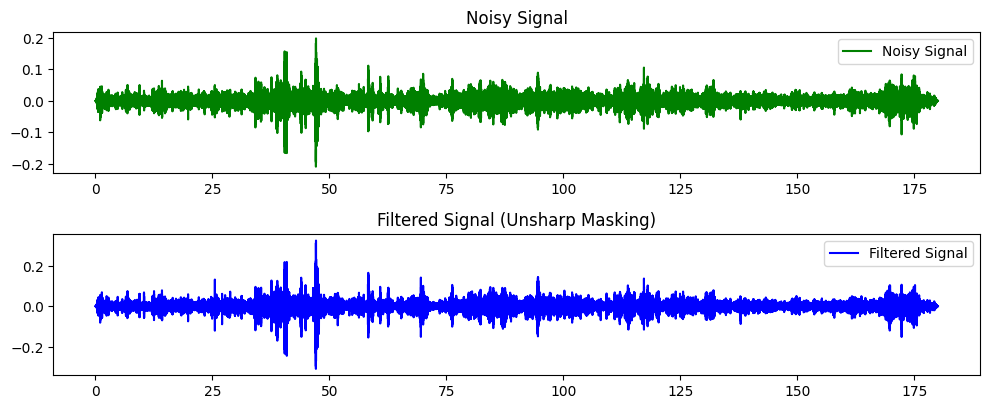

In [13]:
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

def unsharp_mask(audio, sigma=10, amount=1.5):
    blurred = gaussian_filter1d(audio, sigma=sigma)
    mask = audio - blurred
    enhanced_audio = audio + amount * mask
    return enhanced_audio

# Load audio file
file_path = "crowded.wav"
y, sr = librosa.load(file_path, sr=None)

# Generate time axis
t = np.linspace(0, len(y) / sr, num=len(y))

# Apply Unsharp Masking
sigma = 10
amount = 1.5
filtered_signal = unsharp_mask(y, sigma, amount)

# Plot signals
plt.figure(figsize=(10, 8))

# Plot original (noisy) signal
plt.subplot(4, 1, 1)
plt.plot(t, y, label='Noisy Signal', color='g')
plt.legend()
plt.title('Noisy Signal')

# Plot filtered signal (Unsharp Masking)
plt.subplot(4, 1, 2)
plt.plot(t, filtered_signal, label='Filtered Signal', color='b')
plt.legend()
plt.title('Filtered Signal (Unsharp Masking)')

# Menampilkan plot
plt.tight_layout()
plt.show()


##### ***SE***

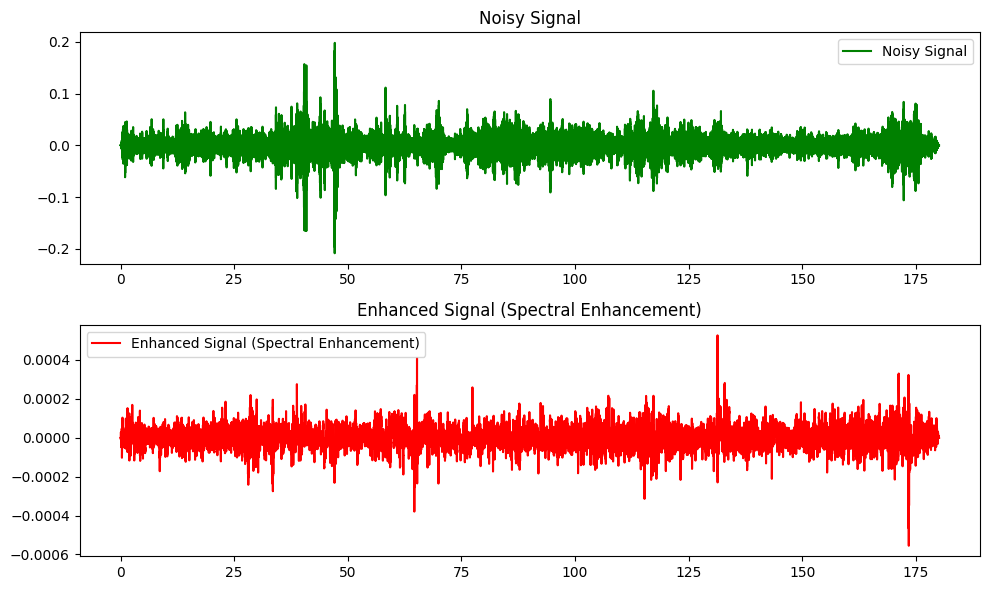

In [14]:
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt
from scipy.fftpack import fft, ifft

def spectral_enhancement(audio, fs=1024):
    fft_signal = fft(audio)  # Transformasi ke domain frekuensi
    freqs = np.fft.fftfreq(len(fft_signal), 1/fs)  # Hitung frekuensi terkait

    enhancement_factor = np.exp(-np.abs(freqs) / 10)  # Faktor peningkatan spektral
    enhanced_fft_signal = fft_signal * enhancement_factor  # Terapkan faktor ke spektrum

    enhanced_audio = np.real(ifft(enhanced_fft_signal))  # Transformasi balik ke domain waktu
    return enhanced_audio

# Load audio file
file_path = "crowded.wav"
y, sr = librosa.load(file_path, sr=None)

# Generate time axis
t = np.linspace(0, len(y) / sr, num=len(y))

# Apply Spectral Enhancement
fs = sr  # Sampling rate dari audio
enhanced_signal = spectral_enhancement(y, fs)

# Plot signals
plt.figure(figsize=(10, 6))

# Plot original (noisy) signal
plt.subplot(2, 1, 1)
plt.plot(t, y, label='Noisy Signal', color='g')
plt.legend()
plt.title('Noisy Signal')

# Plot enhanced signal (Spectral Enhancement)
plt.subplot(2, 1, 2)
plt.plot(t, enhanced_signal, label='Enhanced Signal (Spectral Enhancement)', color='r')
plt.legend()
plt.title('Enhanced Signal (Spectral Enhancement)')

# Menampilkan plot
plt.tight_layout()
plt.show()


##### ***DAF***

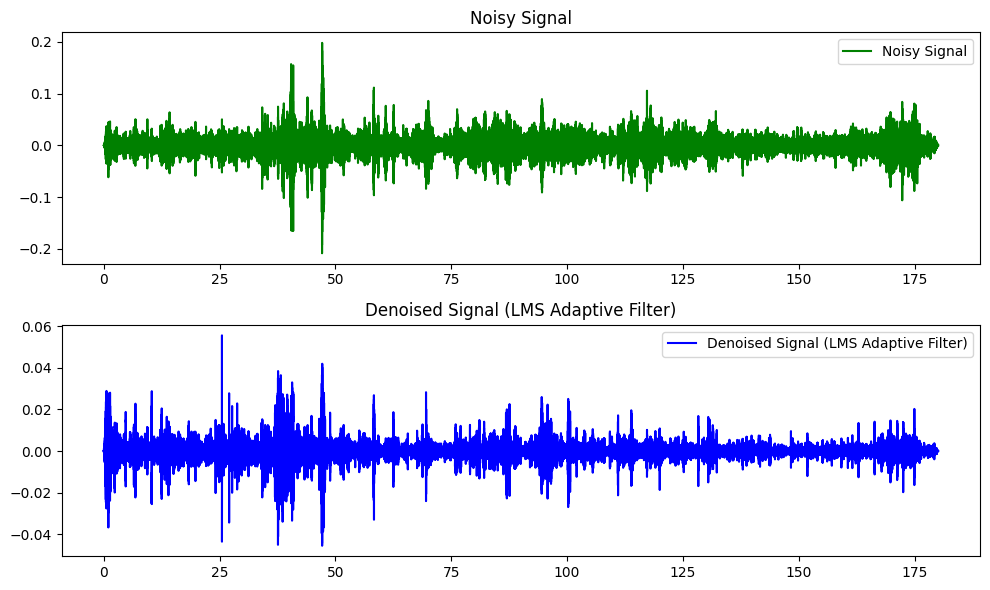

In [15]:
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt

def lms_filter(desired, noise, mu=0.01, num_taps=32):
    """Adaptive LMS filter"""
    N = len(desired)
    w = np.zeros(num_taps)
    y = np.zeros(N)
    e = np.zeros(N)
    
    for n in range(num_taps, N):
        x = noise[n-num_taps:n]
        y[n] = np.dot(w, x)
        e[n] = desired[n] - y[n]
        w += 2 * mu * e[n] * x
        
    return y, e

# Load audio file
file_path = "crowded.wav"
noisy_signal, sr = librosa.load(file_path, sr=None)

# Simulasikan clean signal (bisa diganti dengan sinyal referensi sebenarnya)
clean_signal = noisy_signal.copy()  # Misalkan sinyal asli ada dalam noise

# Apply Adaptive LMS Filtering
num_taps = 32  # Panjang filter
mu = 0.01  # Laju pembelajaran
adaptive_output, denoise_signal = lms_filter(clean_signal, noisy_signal, mu, num_taps)

# Generate time axis
t = np.linspace(0, len(noisy_signal) / sr, num=len(noisy_signal))

# Plot signals
plt.figure(figsize=(10, 6))

# Plot original (noisy) signal
plt.subplot(2, 1, 1)
plt.plot(t, noisy_signal, label='Noisy Signal', color='g')
plt.legend()
plt.title('Noisy Signal')

# Plot enhanced signal (Adaptive Filtering)
plt.subplot(2, 1, 2)
plt.plot(t, denoise_signal, label='Denoised Signal (LMS Adaptive Filter)', color='b')
plt.legend()
plt.title('Denoised Signal (LMS Adaptive Filter)')

# Menampilkan plot
plt.tight_layout()
plt.show()


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_8348\435567372.py:56: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


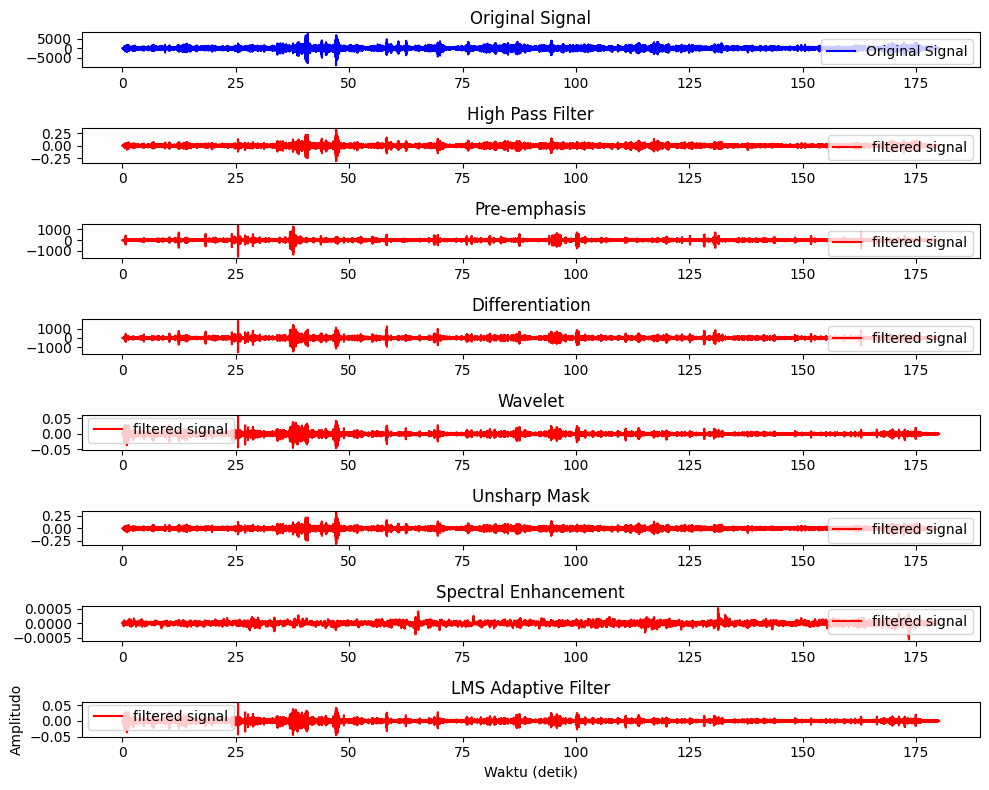

In [24]:
# Plot sinyal asli, sinyal setelah high-pass filter, dan sinyal setelah pre-emphasis
plt.figure(figsize=(10, 8))

# Plot sinyal asli
plt.subplot(8, 1, 1)
plt.plot(t, signal, label='Original Signal', color='b')
plt.legend()
plt.title('Original Signal')

# Plot sinyal setelah high-pass filter
plt.subplot(8, 1, 2)
plt.plot(t, filtered_signal, label='filtered signal', color='r')
plt.legend()
plt.title('High Pass Filter')

# Plot sinyal setelah pre-emphasis
plt.subplot(8, 1, 3)
plt.plot(t, emphasized_signal, label='filtered signal', color='r')
plt.legend()
plt.title('Pre-emphasis')

# Plot sinyal setelah differentiation (turunan pertama)
plt.subplot(8, 1, 4)
plt.plot(diff_time, diff_signal, label='filtered signal', color='r')
plt.legend()
plt.title('Differentiation')

# Plot sinyal yang telah dide-noise dengan wavelet
plt.subplot(8, 1, 5)
plt.plot(t, denoise_signal, label='filtered signal', color='r')
plt.legend()
plt.title('Wavelet')

# Plot filtered signal (Unsharp Masking)
plt.subplot(8, 1, 6)
plt.plot(t, filtered_signal, label='filtered signal', color='r')
plt.legend()
plt.title('Unsharp Mask')

# Plot enhanced signal (Spectral Enhancement)
plt.subplot(8, 1, 7)
plt.plot(t, enhanced_signal, label='filtered signal', color='r')
plt.legend()
plt.title('Spectral Enhancement')

# Plot enhanced signal (Adaptive Filtering)
plt.subplot(8, 1, 8)
plt.plot(t, denoise_signal, label='filtered signal', color='r')
plt.legend()
plt.title('LMS Adaptive Filter')

plt.xlabel('Waktu (detik)')
plt.ylabel('Amplitudo')

# Menampilkan plot
plt.tight_layout()
plt.show()